In [1]:
import os
import torch
import librosa
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from torch.cuda.amp import autocast, GradScaler

In [21]:
import pandas as pd

df = pd.read_csv("C:/Users/Lenovo/Downloads/IR/AI/clotho_captions_development.csv")

# print(df.head())
df = df.head(500)   

print("Samples:", len(df))

Samples: 500


In [22]:
rows = []

for _, row in df.iterrows():
    file = row["file_name"]

    for i in range(1, 6):
        caption = row[f"caption_{i}"]

        rows.append({
            "file": file,
            "caption": caption
        })

clap_df = pd.DataFrame(rows)
print(clap_df.head())

                           file  \
0  Distorted AM Radio noise.wav   
1  Distorted AM Radio noise.wav   
2  Distorted AM Radio noise.wav   
3  Distorted AM Radio noise.wav   
4  Distorted AM Radio noise.wav   

                                             caption  
0        A muddled noise of broken channel of the TV  
1     A television blares the rhythm of a static TV.  
2    Loud television static dips in and out of focus  
3  The loud buzz of static constantly changes pit...  
4  heavy static and the beginnings of a signal on...  


In [23]:
clap_df.to_csv("clotho_clap.csv", index=False)

In [24]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8
EPOCHS = 50
LR = 1e-4
EMB_DIM = 512
AUDIO_ROOT = "development"
MAX_LEN = 512
MAX_STEPS = 30

In [25]:
df = pd.read_csv("clotho_clap.csv")
df["file"] = df["file"].str.strip()


df = df.sample(n=500).reset_index(drop=True)

print("Samples:", len(df))


Samples: 500


In [26]:
audio_cache = {}

def preprocess_audio(path):
    if path in audio_cache:
        return audio_cache[path]

    y, sr = librosa.load(path, sr=48000)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,
        n_fft=1024,
        hop_length=480
    )

    log_mel = librosa.power_to_db(mel)

    # FIX LENGTH
    if log_mel.shape[1] < MAX_LEN:
        pad = MAX_LEN - log_mel.shape[1]
        log_mel = F.pad(torch.tensor(log_mel), (0, pad))
    else:
        log_mel = torch.tensor(log_mel[:, :MAX_LEN])

    tensor = log_mel.unsqueeze(0)
    audio_cache[path] = tensor
    return tensor

In [6]:
class ClothoDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.df = df
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        audio_path = os.path.join(AUDIO_ROOT, row["file"])
        audio = preprocess_audio(audio_path)

        text = self.tokenizer(
            row["caption"],
            padding="max_length",
            truncation=True,
            max_length=16,
            return_tensors="pt"
        )

        return (
            audio,
            text["input_ids"].squeeze(0),
            text["attention_mask"].squeeze(0)
        )


In [7]:
class AudioEncoder(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.fc = nn.Linear(128, emb_dim)

    def forward(self, x):
        x = self.net(x)
        return self.fc(x.view(x.size(0), -1))


class TextEncoder(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.fc = nn.Linear(768, emb_dim)

        #  freeze BERT
        for param in self.bert.parameters():
            param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        cls = out.last_hidden_state[:, 0]
        return self.fc(cls)


class CLAP(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.audio_encoder = AudioEncoder(emb_dim)
        self.text_encoder = TextEncoder(emb_dim)

    def forward(self, audio, input_ids, attention_mask):
        a = self.audio_encoder(audio)
        t = self.text_encoder(input_ids, attention_mask)
        return F.normalize(a, dim=-1), F.normalize(t, dim=-1)

In [8]:
def contrastive_loss(a, t, temp=0.07):
    logits = a @ t.T / temp
    labels = torch.arange(len(logits)).to(logits.device)

    return (F.cross_entropy(logits, labels) +
            F.cross_entropy(logits.T, labels)) / 2


In [49]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

dataset = ClothoDataset(df, tokenizer)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

model = CLAP(EMB_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler = GradScaler()
criterion = ContrastiveLoss()

/tmp/ipykernel_53651/639274516.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/home/ubuntu/mtp/mtp/lib/python3.12/site-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


In [28]:
epoch_losses = []
batch_losses = []
grad_norms = []
similarities_all = []

for epoch in range(EPOCHS):
    total_loss = 0

    for i, (audio, input_ids, mask) in enumerate(loader):
        if i >= MAX_STEPS:
            break

        audio = audio.to(DEVICE)
        input_ids = input_ids.to(DEVICE)
        mask = mask.to(DEVICE)

        optimizer.zero_grad()

        with autocast():
            a, t = model(audio, input_ids, mask)
            loss = contrastive_loss(a, t)

        scaler.scale(loss).backward()

        #  Gradient norm
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item()
        grad_norms.append(total_norm)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        batch_losses.append(loss.item())   # 

        #  store similarity
        with torch.no_grad():
            sims = (a @ t.T).detach().cpu()
            similarities_all.append(sims)

    avg_loss = total_loss / MAX_STEPS
    epoch_losses.append(avg_loss)

    print(f"Epoch {epoch}: {avg_loss:.4f}")

/tmp/ipykernel_53651/1064526686.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/home/ubuntu/mtp/mtp/lib/python3.12/site-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(


Epoch 0: 2.0904
Epoch 1: 2.0693
Epoch 2: 2.0259
Epoch 3: 1.9685
Epoch 4: 1.9305
Epoch 5: 1.9135
Epoch 6: 1.8825
Epoch 7: 1.8576
Epoch 8: 1.8191
Epoch 9: 1.7674
Epoch 10: 1.6521
Epoch 11: 1.6612
Epoch 12: 1.6388
Epoch 13: 1.6044
Epoch 14: 1.6241
Epoch 15: 1.5314
Epoch 16: 1.4542
Epoch 17: 1.4303
Epoch 18: 1.4221
Epoch 19: 1.3643
Epoch 20: 1.3122
Epoch 21: 1.2637
Epoch 22: 1.1891
Epoch 23: 1.2035
Epoch 24: 1.0563
Epoch 25: 1.1159
Epoch 26: 1.1239
Epoch 27: 1.0279
Epoch 28: 0.9825
Epoch 29: 0.9613
Epoch 30: 0.9701
Epoch 31: 0.8656
Epoch 32: 0.8876
Epoch 33: 0.8024
Epoch 34: 0.7752
Epoch 35: 0.7603
Epoch 36: 0.6980
Epoch 37: 0.6318
Epoch 38: 0.6828
Epoch 39: 0.5840
Epoch 40: 0.6350
Epoch 41: 0.5638
Epoch 42: 0.5034
Epoch 43: 0.6228
Epoch 44: 0.5190
Epoch 45: 0.4906
Epoch 46: 0.4979
Epoch 47: 0.4383
Epoch 48: 0.4160
Epoch 49: 0.4425


In [30]:
torch.save(model.state_dict(), "clap_fast.pth")

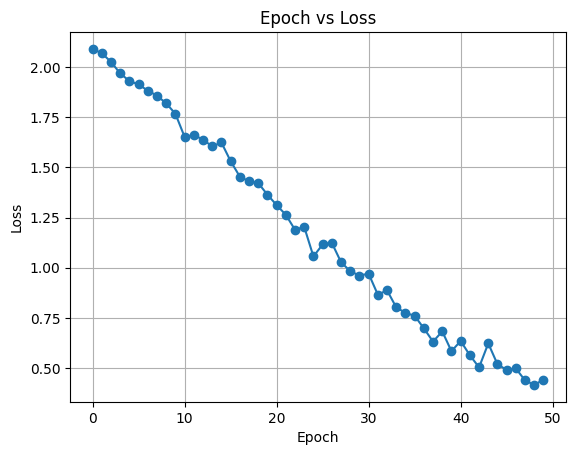

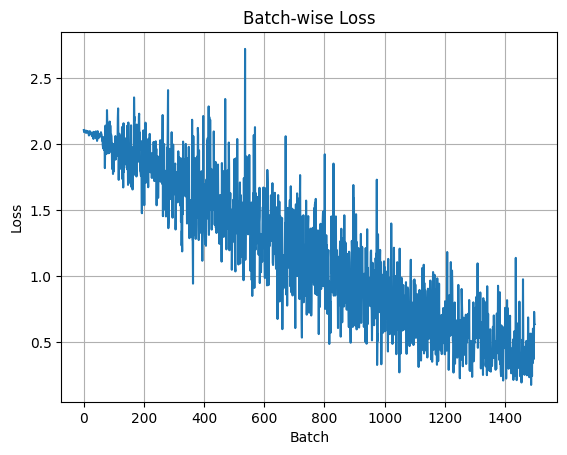

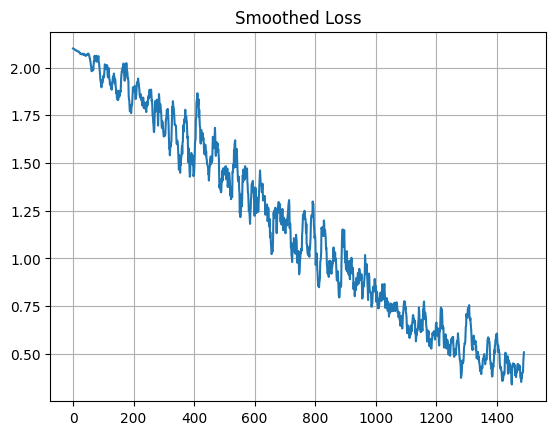

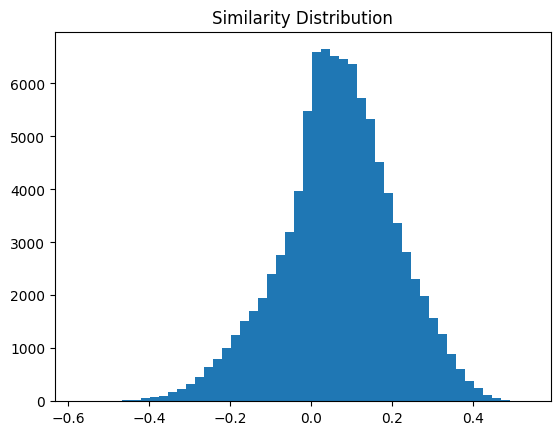

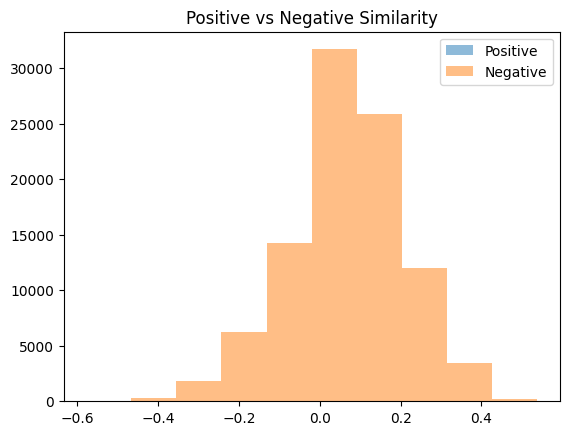

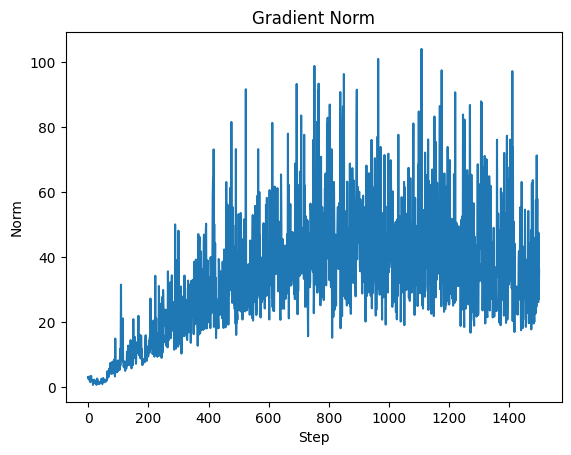

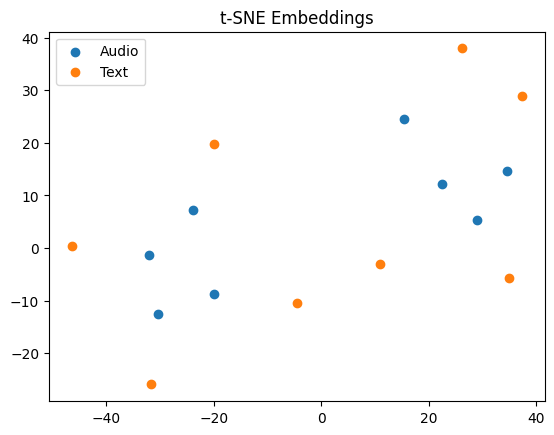

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

# =========================
# 1. Epoch vs Loss
# =========================
plt.figure()
plt.plot(epoch_losses, marker='o')
plt.title("Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.savefig("epoch_loss.png")

# =========================
# 2. Batch Loss
# =========================
plt.figure()
plt.plot(batch_losses)
plt.title("Batch-wise Loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.grid()
plt.savefig("batch_loss.png")

# =========================
# 3. Smoothed Loss
# =========================
smooth = np.convolve(batch_losses, np.ones(10)/10, mode='valid')

plt.figure()
plt.plot(smooth)
plt.title("Smoothed Loss")
plt.grid()
plt.savefig("smoothed_loss.png")

# =========================
# 4. Similarity Distribution
# =========================
sims = torch.cat(similarities_all).numpy()

plt.figure()
plt.hist(sims.flatten(), bins=50)
plt.title("Similarity Distribution")
plt.savefig("similarity_dist.png")

# =========================
# 5. Positive vs Negative
# =========================
pos = sims.diagonal()
neg = sims.flatten()

plt.figure()
plt.hist(pos, alpha=0.5, label="Positive")
plt.hist(neg, alpha=0.5, label="Negative")
plt.legend()
plt.title("Positive vs Negative Similarity")
plt.savefig("pos_vs_neg.png")

# =========================
# 6. Gradient Norm
# =========================
plt.figure()
plt.plot(grad_norms)
plt.title("Gradient Norm")
plt.xlabel("Step")
plt.ylabel("Norm")
plt.savefig("grad_norm.png")

# =========================
# 7. Embedding Visualization (t-SNE)
# =========================
# take last batch embeddings
a_np = a.detach().cpu().numpy()
t_np = t.detach().cpu().numpy()

embeddings = np.vstack([a_np, t_np])

tsne = TSNE(n_components=2, perplexity=5)
proj = tsne.fit_transform(embeddings)

plt.figure()
plt.scatter(proj[:len(a_np), 0], proj[:len(a_np), 1], label="Audio")
plt.scatter(proj[len(a_np):, 0], proj[len(a_np):, 1], label="Text")
plt.legend()
plt.title("t-SNE Embeddings")
plt.savefig("tsne.png")

plt.show()

Inference

In [31]:
import torch
import torch.nn.functional as F
import librosa

from transformers import BertTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# load model
model = CLAP(512).to(DEVICE)
model.load_state_dict(torch.load("clap_fast.pth", map_location=DEVICE))
model.eval()

CLAP(
  (audio_encoder): AudioEncoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (fc): Linear(in_features=128, out_features=512, bias=True)
  )
  (text_encoder): TextEncoder(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p

In [32]:
MAX_LEN = 512

def preprocess_audio(path):
    y, sr = librosa.load(path, sr=48000)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,
        n_fft=1024,
        hop_length=480
    )

    log_mel = librosa.power_to_db(mel)

    if log_mel.shape[1] < MAX_LEN:
        pad = MAX_LEN - log_mel.shape[1]
        log_mel = F.pad(torch.tensor(log_mel), (0, pad))
    else:
        log_mel = torch.tensor(log_mel[:, :MAX_LEN])

    return log_mel.unsqueeze(0)

In [33]:
labels = [
    "dog barking",
    "rain falling",
    "car engine",
    "people talking",
    "music playing"
]

In [34]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

text_inputs = tokenizer(
    labels,
    padding=True,
    truncation=True,
    return_tensors="pt"
).to(DEVICE)

with torch.no_grad():
    text_emb = model.text_encoder(
        text_inputs["input_ids"],
        text_inputs["attention_mask"]
    )
    text_emb = F.normalize(text_emb, dim=-1)

In [39]:
audio_path = "C:/Users/Lenovo/Downloads/IR/AI/Clotho/RainPatter.wav"   # your test file

audio = preprocess_audio(audio_path).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    audio_emb = model.audio_encoder(audio)
    audio_emb = F.normalize(audio_emb, dim=-1)

# similarity
similarity = audio_emb @ text_emb.T
scores = similarity.squeeze().cpu().numpy()

In [40]:
import numpy as np

pred_idx = np.argmax(scores)
print("Predicted:", labels[pred_idx])

# show all scores
for label, score in zip(labels, scores):
    print(f"{label}: {score:.4f}")

Predicted: rain falling
dog barking: -0.0571
rain falling: 0.2446
car engine: -0.0954
people talking: 0.0000
music playing: -0.3027


In [41]:
audio_path = "C:/Users/Lenovo/Downloads/IR/AI/Clotho/Dogs_Barking.wav"   # your test file

audio = preprocess_audio(audio_path).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    audio_emb = model.audio_encoder(audio)
    audio_emb = F.normalize(audio_emb, dim=-1)

# similarity
similarity = audio_emb @ text_emb.T
scores = similarity.squeeze().cpu().numpy()

In [42]:
import numpy as np

pred_idx = np.argmax(scores)
print("Predicted:", labels[pred_idx])

# show all scores
for label, score in zip(labels, scores):
    print(f"{label}: {score:.4f}")

Predicted: music playing
dog barking: 0.1119
rain falling: -0.2344
car engine: -0.0654
people talking: -0.1495
music playing: 0.2167


Quantitative results

In [43]:
audio_embs = []
text_embs = []

model.eval()

with torch.no_grad():
    for audio, input_ids, mask in loader:
        audio = audio.to(DEVICE)
        input_ids = input_ids.to(DEVICE)
        mask = mask.to(DEVICE)

        a, t = model(audio, input_ids, mask)

        audio_embs.append(a)
        text_embs.append(t)

audio_embs = torch.cat(audio_embs)   
text_embs = torch.cat(text_embs)     

In [44]:
sim_matrix = audio_embs @ text_embs.T   # [N x N]

In [45]:
def recall_at_k(sim_matrix, k=1, mode="audio_to_text"):
    N = sim_matrix.shape[0]
    correct = 0

    for i in range(N):
        if mode == "audio_to_text":
            sims = sim_matrix[i]   # row
        else:
            sims = sim_matrix[:, i]   # column

        topk = torch.topk(sims, k).indices

        if i in topk:
            correct += 1

    return correct / N

In [47]:
for k in [1, 5, 10]:
    r_at = recall_at_k(sim_matrix, k, mode="audio_to_text") * 100
    t_at = recall_at_k(sim_matrix, k, mode="text_to_audio") * 100

    print(f"A→T R@{k}: {r_at:.1f}")
    print(f"T→A R@{k}: {t_at:.1f}")

A→T R@1: 11.6
T→A R@1: 17.4
A→T R@5: 41.6
T→A R@5: 52.0
A→T R@10: 60.2
T→A R@10: 69.4


Improvement in the model

In [48]:
class ContrastiveLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_temp = nn.Parameter(torch.log(torch.tensor(0.07)))

    def forward(self, a, t):
        temp = torch.exp(self.log_temp)

        logits = (a @ t.T) / temp
        labels = torch.arange(len(logits)).to(logits.device)

        loss_a = F.cross_entropy(logits, labels)
        loss_t = F.cross_entropy(logits.T, labels)

        return (loss_a + loss_t) / 2

In [50]:
epoch_losses = []
batch_losses = []
grad_norms = []
similarities_all = []

for epoch in range(EPOCHS):
    total_loss = 0

    for i, (audio, input_ids, mask) in enumerate(loader):
        if i >= MAX_STEPS:
            break

        audio = audio.to(DEVICE)
        input_ids = input_ids.to(DEVICE)
        mask = mask.to(DEVICE)

        optimizer.zero_grad()

        with autocast():
            a, t = model(audio, input_ids, mask)
            loss = criterion(a, t)

        scaler.scale(loss).backward()

        #  Gradient norm
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item()
        grad_norms.append(total_norm)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        batch_losses.append(loss.item())   

        #  store similarity
        with torch.no_grad():
            sims = (a @ t.T).detach().cpu()
            similarities_all.append(sims)

    avg_loss = total_loss / MAX_STEPS
    epoch_losses.append(avg_loss)

    print(f"Epoch {epoch}: {avg_loss:.4f}")

/tmp/ipykernel_53651/249984860.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/home/ubuntu/mtp/mtp/lib/python3.12/site-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(


Epoch 0: 2.0896
Epoch 1: 2.0770
Epoch 2: 2.0529
Epoch 3: 2.0090
Epoch 4: 1.9657
Epoch 5: 1.8855
Epoch 6: 1.9185
Epoch 7: 1.8320
Epoch 8: 1.7867
Epoch 9: 1.7487
Epoch 10: 1.6979
Epoch 11: 1.7165
Epoch 12: 1.6472
Epoch 13: 1.6621
Epoch 14: 1.6221
Epoch 15: 1.4838
Epoch 16: 1.5037
Epoch 17: 1.4393
Epoch 18: 1.3405
Epoch 19: 1.3713
Epoch 20: 1.3711
Epoch 21: 1.2861
Epoch 22: 1.2625
Epoch 23: 1.4347
Epoch 24: 1.1592
Epoch 25: 1.1635
Epoch 26: 1.1392
Epoch 27: 1.1414
Epoch 28: 1.0079
Epoch 29: 0.9982
Epoch 30: 0.9242
Epoch 31: 0.9558
Epoch 32: 0.8659
Epoch 33: 0.9181
Epoch 34: 0.8036
Epoch 35: 0.8109
Epoch 36: 0.7011
Epoch 37: 0.7303
Epoch 38: 0.6687
Epoch 39: 0.6041
Epoch 40: 0.6940
Epoch 41: 0.6374
Epoch 42: 0.6122
Epoch 43: 0.6102
Epoch 44: 0.5075
Epoch 45: 0.5556
Epoch 46: 0.5524
Epoch 47: 0.4882
Epoch 48: 0.4836
Epoch 49: 0.4416


In [51]:
torch.save(model.state_dict(), "clap_fast_improved.pth")

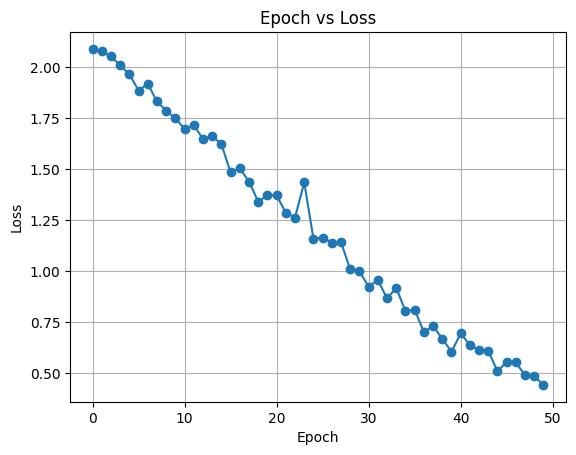

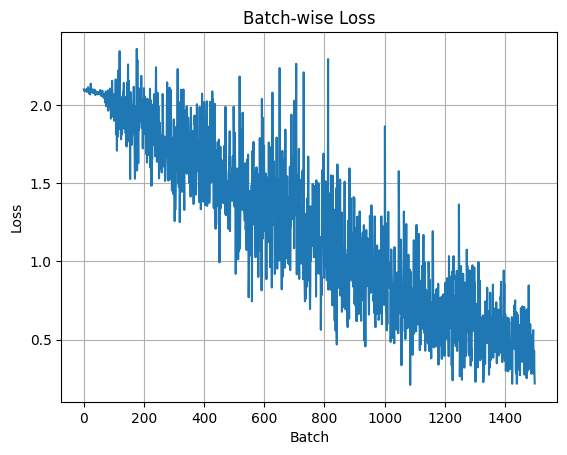

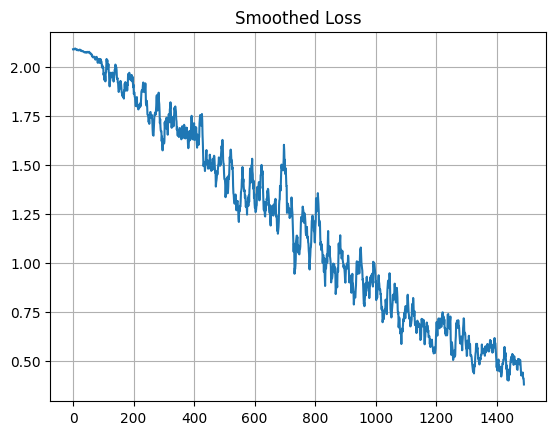

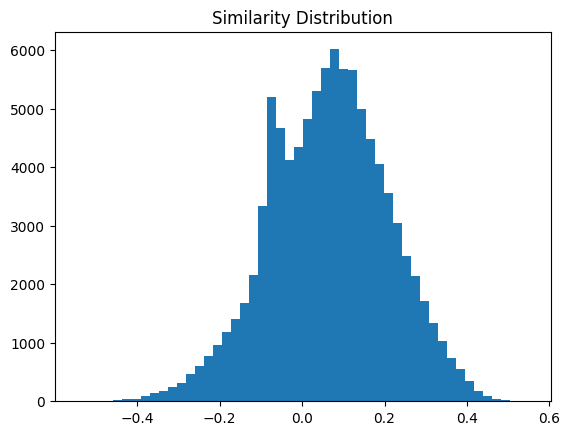

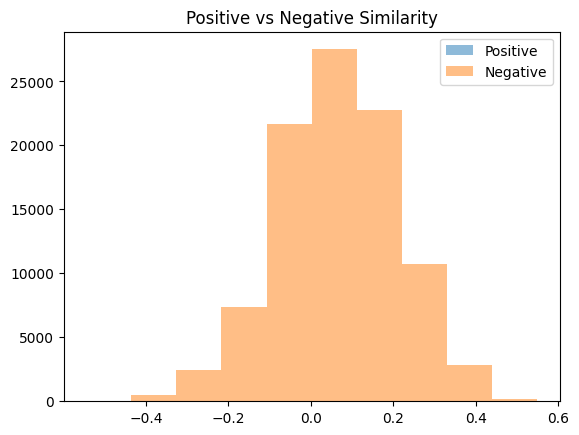

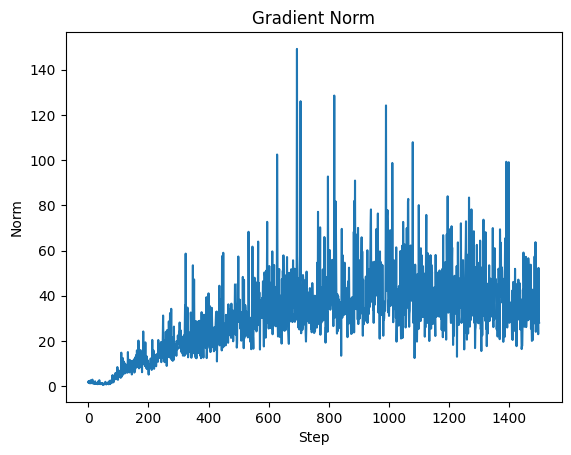

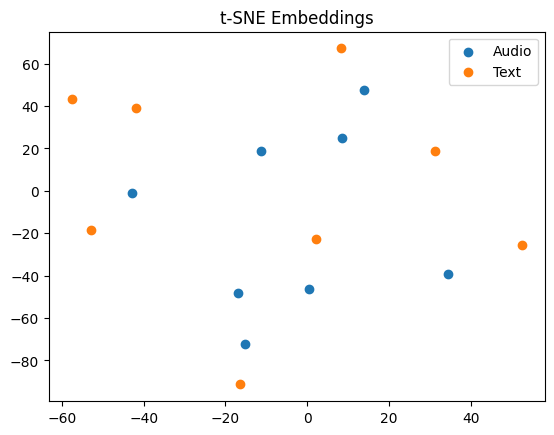

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

# =========================
# 1. Epoch vs Loss
# =========================
plt.figure()
plt.plot(epoch_losses, marker='o')
plt.title("Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.savefig("epoch_loss_improved.png")

# =========================
# 2. Batch Loss
# =========================
plt.figure()
plt.plot(batch_losses)
plt.title("Batch-wise Loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.grid()
plt.savefig("batch_loss_improved.png")

# =========================
# 3. Smoothed Loss
# =========================
smooth = np.convolve(batch_losses, np.ones(10)/10, mode='valid')

plt.figure()
plt.plot(smooth)
plt.title("Smoothed Loss")
plt.grid()
plt.savefig("smoothed_loss_improved.png")

# =========================
# 4. Similarity Distribution
# =========================
sims = torch.cat(similarities_all).numpy()

plt.figure()
plt.hist(sims.flatten(), bins=50)
plt.title("Similarity Distribution")
plt.savefig("similarity_dist_improved.png")

# =========================
# 5. Positive vs Negative
# =========================
pos = sims.diagonal()
neg = sims.flatten()

plt.figure()
plt.hist(pos, alpha=0.5, label="Positive")
plt.hist(neg, alpha=0.5, label="Negative")
plt.legend()
plt.title("Positive vs Negative Similarity")
plt.savefig("pos_vs_neg_improved.png")

# =========================
# 6. Gradient Norm
# =========================
plt.figure()
plt.plot(grad_norms)
plt.title("Gradient Norm")
plt.xlabel("Step")
plt.ylabel("Norm")
plt.savefig("grad_norm_improved.png")

# =========================
# 7. Embedding Visualization (t-SNE)
# =========================
# take last batch embeddings
a_np = a.detach().cpu().numpy()
t_np = t.detach().cpu().numpy()

embeddings = np.vstack([a_np, t_np])

tsne = TSNE(n_components=2, perplexity=5)
proj = tsne.fit_transform(embeddings)

plt.figure()
plt.scatter(proj[:len(a_np), 0], proj[:len(a_np), 1], label="Audio")
plt.scatter(proj[len(a_np):, 0], proj[len(a_np):, 1], label="Text")
plt.legend()
plt.title("t-SNE Embeddings")
plt.savefig("tsne_improved.png")

plt.show()

In [53]:
import torch
import torch.nn.functional as F
import librosa

from transformers import BertTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# load model
model = CLAP(512).to(DEVICE)
model.load_state_dict(torch.load("clap_fast_improved.pth", map_location=DEVICE))
model.eval()

CLAP(
  (audio_encoder): AudioEncoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (fc): Linear(in_features=128, out_features=512, bias=True)
  )
  (text_encoder): TextEncoder(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p

In [54]:
audio_path = "C:/Users/Lenovo/Downloads/IR/AI/Clotho/Dogs_Barking.wav"   # your test file

audio = preprocess_audio(audio_path).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    audio_emb = model.audio_encoder(audio)
    audio_emb = F.normalize(audio_emb, dim=-1)

# similarity
similarity = audio_emb @ text_emb.T
scores = similarity.squeeze().cpu().numpy()


import numpy as np

pred_idx = np.argmax(scores)
print("Predicted:", labels[pred_idx])

# show all scores
for label, score in zip(labels, scores):
    print(f"{label}: {score:.4f}")

Predicted: dog barking
dog barking: 0.0462
rain falling: 0.0181
car engine: 0.0035
people talking: -0.0744
music playing: -0.0645


In [55]:
audio_embs = []
text_embs = []

model.eval()

with torch.no_grad():
    for audio, input_ids, mask in loader:
        audio = audio.to(DEVICE)
        input_ids = input_ids.to(DEVICE)
        mask = mask.to(DEVICE)

        a, t = model(audio, input_ids, mask)

        audio_embs.append(a)
        text_embs.append(t)

audio_embs = torch.cat(audio_embs)   
text_embs = torch.cat(text_embs)     

In [56]:
sim_matrix = audio_embs @ text_embs.T   # [N x N]

In [57]:
def recall_at_k(sim_matrix, k=1, mode="audio_to_text"):
    N = sim_matrix.shape[0]
    correct = 0

    for i in range(N):
        if mode == "audio_to_text":
            sims = sim_matrix[i]   # row
        else:
            sims = sim_matrix[:, i]   # column

        topk = torch.topk(sims, k).indices

        if i in topk:
            correct += 1

    return correct / N

In [58]:
for k in [1, 5, 10]:
    r_at = recall_at_k(sim_matrix, k, mode="audio_to_text") * 100
    t_at = recall_at_k(sim_matrix, k, mode="text_to_audio") * 100

    print(f"A→T R@{k}: {r_at:.1f}")
    print(f"T→A R@{k}: {t_at:.1f}")

A→T R@1: 9.6
T→A R@1: 17.0
A→T R@5: 40.0
T→A R@5: 51.0
A→T R@10: 60.8
T→A R@10: 70.4
